# Notebook 06 · Infraestructura eléctrica OSM/Overpass en Iberia

## Objetivo

En este notebook preparamos la infraestructura eléctrica utilizada en el análisis territorial de centros de datos sostenibles.

Trabajamos con elementos de OpenStreetMap:

- líneas y cables eléctricos;
- líneas de alta tensión;
- subestaciones y estaciones eléctricas.

El ámbito incluye España peninsular, Portugal continental y Andorra.

## Metodología

Primero reutilizamos las capas procesadas disponibles en Kaggle Input. Si no existen, mantenemos la consulta a Overpass API como alternativa trazable.

Validamos las geometrías, los atributos de tensión y el sistema de coordenadas. Procesamos las capas en EPSG:3035 y utilizamos EPSG:4326 para las visualizaciones.

## Uso en el TFB

El Notebook 10 utiliza estas capas para calcular:

- longitud de líneas eléctricas;
- longitud de líneas de alta tensión;
- número de subestaciones;
- densidades territoriales de la infraestructura eléctrica.

Los datos OSM representan la infraestructura cartografiada, pero no informan sobre capacidad disponible, demanda, congestión, precios o viabilidad real de conexión. Por ello, los utilizamos como indicador territorial preliminar y no como un estudio eléctrico definitivo.

In [1]:
# LIBRERÍAS GEOESPACIALES
%pip install -q geopandas pyogrio

Note: you may need to restart the kernel to use updated packages.


In [2]:
# LIBRERÍAS Y CONFIGURACIÓN
from pathlib import Path
from datetime import datetime
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Directorios
BASE_DIR = Path("/kaggle/working")
INPUT_DIR = Path("/kaggle/input")
NOMBRE_BLOQUE = "06_infraestructura_electrica_osm_overpass_iberia"
OUT_DIR = BASE_DIR / NOMBRE_BLOQUE
RAW_DIR = OUT_DIR / "raw"
PROCESSED_DIR = OUT_DIR / "processed"
GPKG_DIR = PROCESSED_DIR / "geopackage"
TABLAS_DIR = OUT_DIR / "tablas"
FIGURES_DIR = OUT_DIR / "figures"
DASHBOARD_DIR = OUT_DIR / "dashboard"

for carpeta in [
    RAW_DIR,
    GPKG_DIR,
    TABLAS_DIR,
    FIGURES_DIR,
    DASHBOARD_DIR
]:
    carpeta.mkdir(parents=True, exist_ok=True)

# Parámetros
FECHA_EJECUCION = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
CRS_GEOGRAFICO = "EPSG:4326"
CRS_METRICO = "EPSG:3035"
OESTE, SUR, ESTE, NORTE = -10.0, 35.0, 4.0, 44.0

print("Entorno preparado:", OUT_DIR)

Entorno preparado: /kaggle/working/06_infraestructura_electrica_osm_overpass_iberia


# Fuentes y criterio temporal

Utilizamos OpenStreetMap como fuente de líneas, cables y subestaciones eléctricas. Primero buscamos las capas procesadas en Kaggle Input. Si no están disponibles, mantenemos Overpass API como alternativa de descarga trazable.

Tratamos la infraestructura eléctrica como información geoespacial semiestática. Por ello, documentamos la fecha de consulta o reutilización de los datos, en lugar de aplicar una ventana temporal climática.

OSM representa la infraestructura cartografiada, pero no informa sobre capacidad disponible, congestión ni viabilidad de conexión. Redeia, REN, ENTSO-E y FEDA se documentan como fuentes oficiales de referencia y contraste contextual, pero no sustituyen las capas OSM utilizadas en este notebook.

Los resultados se utilizan como indicadores territoriales de presencia y densidad de infraestructura eléctrica, no como un estudio técnico de conexión a la red.

In [3]:
# FUENTES Y TRAZABILIDAD
ENDPOINTS_OVERPASS = [
    "https://overpass-api.de/api/interpreter",
    "https://overpass.kumi.systems/api/interpreter"
]
fuentes_electricas = pd.DataFrame(
    [
        ["OSM / Overpass", "Iberia y Andorra", "Principal"],
        ["Redeia", "España", "Contraste"],
        ["REN", "Portugal", "Contraste"],
        ["ENTSO-E", "Europa", "Contexto"],
        ["FEDA", "Andorra", "Contraste"]
    ],
    columns=["fuente", "territorio", "uso"]
)
fuentes_electricas["fecha_ejecucion"] = FECHA_EJECUCION
ruta_fuentes_electricas = (
    TABLAS_DIR / "tabla_fuentes_infraestructura_electrica.csv"
)
fuentes_electricas.to_csv(ruta_fuentes_electricas, index=False)
print("Fuentes documentadas:", len(fuentes_electricas))
display(fuentes_electricas)

Fuentes documentadas: 5


,fuente,territorio,uso,fecha_ejecucion
0,OSM / Overpass,Iberia y Andorra,Principal,2026-09-18 13:44:21
1,Redeia,España,Contraste,2026-09-18 13:44:21
2,REN,Portugal,Contraste,2026-09-18 13:44:21
3,ENTSO-E,Europa,Contexto,2026-09-18 13:44:21
4,FEDA,Andorra,Contraste,2026-09-18 13:44:21


In [4]:
# CARGA DE DATOS
from shutil import copy2

nombre_gpkg = (
    "infraestructura_electrica_iberia_osm_final_epsg3035.gpkg"
)
ruta_input = next(INPUT_DIR.rglob(nombre_gpkg), None)
ruta_gpkg_electrica = GPKG_DIR / nombre_gpkg
USAR_INPUT = ruta_input is not None

if USAR_INPUT:
    copy2(ruta_input, ruta_gpkg_electrica)
    nombres_capas = {
        "lineas_cables": "lineas_cables_3035",
        "lineas_alta_tension":
            "lineas_cables_alta_tension_110kv_3035",
        "subestaciones":
            "subestaciones_representativas_3035"
    }
    capas = {
        nombre: gpd.read_file(
            ruta_gpkg_electrica,
            layer=capa
        )
        for nombre, capa in nombres_capas.items()
    }
    if any(
        capa.empty or capa.crs.to_epsg() != 3035
        for capa in capas.values()
    ):
        raise ValueError("Las capas no son válidas.")
    lineas_cables_3035 = capas["lineas_cables"]
    lineas_alta_tension_3035 = capas["lineas_alta_tension"]
    subestaciones_3035 = capas["subestaciones"]
    conteos = {
        nombre: len(capa)
        for nombre, capa in capas.items()
    }
    print("Origen: Kaggle Input")
    print("Conteos:", conteos)

else:
    capas = {}
    print("Sin Kaggle Input: utilizaremos Overpass.")
pd.DataFrame([{
    "origen": "Kaggle Input" if USAR_INPUT else "Overpass",
    "ruta": str(ruta_input) if USAR_INPUT else "",
    "fecha_ejecucion": FECHA_EJECUCION
}]).to_csv(
    TABLAS_DIR / "tabla_estado_carga_electrica.csv",
    index=False
)

Origen: Kaggle Input
Conteos: {'lineas_cables': 124709, 'lineas_alta_tension': 11450, 'subestaciones': 23366}


In [5]:
# BBOX PARA OVERPASS
BBOX_OVERPASS = f"{SUR},{OESTE},{NORTE},{ESTE}"

pd.DataFrame([{
    "bbox": BBOX_OVERPASS,
    "orden": "sur,oeste,norte,este",
    "fecha_ejecucion": FECHA_EJECUCION
}]).to_csv(
    TABLAS_DIR / "tabla_bbox_overpass.csv",
    index=False
)

print("BBOX Overpass:", BBOX_OVERPASS)

BBOX Overpass: 35.0,-10.0,44.0,4.0


# Descarga alternativa mediante teselas

Los datos principales proceden de Kaggle Input. Si no estuvieran disponibles, dividimos el ámbito de estudio en teselas para consultar Overpass sin sobrecargar el servicio.

La descarga alternativa obtiene:

- `power=line` y `power=minor_line`;
- `power=cable`;
- `power=substation` y `power=station`.

Cada tesela se consulta por separado y su respuesta JSON se guarda en `raw/`. Este procedimiento mejora la trazabilidad y permite reintentar únicamente las consultas fallidas.

En la ejecución actual no utilizamos esta descarga porque las capas procesadas ya están disponibles en Kaggle Input.

In [6]:
# TESELAS PARA OVERPASS
from itertools import product

coordenadas = product(
    range(int(SUR), int(NORTE)),
    range(int(OESTE), int(ESTE))
)
teselas_overpass_df = pd.DataFrame([
    {
        "id_tesela": f"tile_{numero:04d}",
        "bbox_overpass": f"{lat},{lon},{lat + 1},{lon + 1}"
    }
    for numero, (lat, lon) in enumerate(coordenadas, start=1)
])
teselas_overpass_df.to_csv(
    TABLAS_DIR / "tabla_teselas_overpass.csv",
    index=False
)
print("Teselas creadas:", len(teselas_overpass_df))
display(teselas_overpass_df.head())

Teselas creadas: 126


,id_tesela,bbox_overpass
0,tile_0001,"35,-10,36,-9"
1,tile_0002,"35,-9,36,-8"
2,tile_0003,"35,-8,36,-7"
3,tile_0004,"35,-7,36,-6"
4,tile_0005,"35,-6,36,-5"


In [7]:
# CONSULTA OVERPASS
TIPOS_POWER = (
    "line",
    "minor_line",
    "cable",
    "substation",
    "station"
)

def construir_consulta_overpass(bbox):
    filtros = "\n".join(
        (
            f'node["power"="{tipo}"]({bbox});\n'
            f'way["power"="{tipo}"]({bbox});'
        )
        for tipo in TIPOS_POWER
    )
    return (
        "[out:json][timeout:180];\n"
        f"({filtros});\n"
        "out body;\n"
        ">;\n"
        "out skel qt;"
    )

consulta_prueba = construir_consulta_overpass(
    "40,-4,41,-3"
)

(RAW_DIR / "consulta_overpass_prueba.txt").write_text(
    consulta_prueba,
    encoding="utf-8"
)

print(consulta_prueba)

[out:json][timeout:180];
(node["power"="line"](40,-4,41,-3);
way["power"="line"](40,-4,41,-3);
node["power"="minor_line"](40,-4,41,-3);
way["power"="minor_line"](40,-4,41,-3);
node["power"="cable"](40,-4,41,-3);
way["power"="cable"](40,-4,41,-3);
node["power"="substation"](40,-4,41,-3);
way["power"="substation"](40,-4,41,-3);
node["power"="station"](40,-4,41,-3);
way["power"="station"](40,-4,41,-3););
out body;
>;
out skel qt;


In [8]:
# TENSIÓN ELÉCTRICA OSM
import re

def extraer_tension_kv(valor):
    if valor is None or pd.isna(valor):
        return None
    resultados = []
    for numero, unidad in re.findall(
        r"(\d+(?:[\.,]\d+)?)\s*(kv|v)?",
        str(valor).lower()
    ):
        numero = float(numero.replace(",", "."))
        if numero > 0:
            resultados.append(
                numero if unidad == "kv" else numero / 1000
            )
    return max(resultados) if resultados else None

def clasificar_tension(tension):
    if tension is None:
        return "sin_dato"
    if tension < 45:
        return "baja_media"
    if tension < 110:
        return "alta_45_110"
    if tension < 220:
        return "alta_110_220"
    return "muy_alta_220_mas"

# Comprobaciones básicas
casos_prueba = {
    "20000;400": 20,
    "400000;225000;63000": 400,
    "132000": 132,
    "132 kV": 132
}
for valor, esperado in casos_prueba.items():
    assert extraer_tension_kv(valor) == esperado

print("Parser de tensión validado:", len(casos_prueba), "casos")

Parser de tensión validado: 4 casos


# Obtención completa de la infraestructura eléctrica

El notebook utiliza dos caminos:

1. Reutiliza las capas procesadas disponibles en Kaggle Input.
2. Si no existen, descarga las 126 teselas mediante Overpass API.

La descarga alternativa reutiliza los JSON existentes, consulta las teselas pendientes y registra errores. A continuación reconstruimos las geometrías, eliminamos duplicados y interpretamos el atributo `voltage`.

Los dos caminos preparan las mismas capas de trabajo:

- líneas y cables eléctricos;
- líneas de alta tensión;
- subestaciones representativas;
- capas proyectadas en EPSG:3035.

In [9]:
# DESCARGA ALTERNATIVA CON OVERPASS
if USAR_INPUT:
    print("Descarga omitida: utilizamos Kaggle Input.")

else:
    import json
    import time
    import requests

    JSON_DIR = RAW_DIR / "osm_overpass"
    JSON_DIR.mkdir(exist_ok=True)

    registros = []
    for _, tesela in teselas_overpass_df.iterrows():
        id_tesela = tesela["id_tesela"]
        ruta_json = JSON_DIR / f"{id_tesela}.json"

        if ruta_json.exists():
            estado = "reutilizada"
            origen = "JSON local"
            error = ""
        else:
            consulta = construir_consulta_overpass(
                tesela["bbox_overpass"]
            )
            datos = None
            error = ""

            for endpoint in ENDPOINTS_OVERPASS:
                try:
                    respuesta = requests.post(
                        endpoint,
                        data={"data": consulta},
                        timeout=180
                    )
                    respuesta.raise_for_status()
                    datos = respuesta.json()
                    origen = endpoint
                    break
                except Exception as excepcion:
                    error = str(excepcion)
                    
            if datos is not None:
                ruta_json.write_text(
                    json.dumps(datos),
                    encoding="utf-8"
                )
                estado = "descargada"
            else:
                estado = "error"
                origen = ""
            time.sleep(1)
        registros.append({
            "id_tesela": id_tesela,
            "estado": estado,
            "origen": origen,
            "error": error
        })
    log_descargas = pd.DataFrame(registros)
    log_descargas.to_csv(
        TABLAS_DIR / "tabla_descargas_overpass.csv",
        index=False
    )
    print(log_descargas["estado"].value_counts())

Descarga omitida: utilizamos Kaggle Input.


In [10]:
# CAPAS ELÉCTRICAS FINALES
import json
from shapely.geometry import Point, LineString

def procesar_json_overpass():
    registros = []
    JSON_DIR = RAW_DIR / "osm_overpass"

    for ruta in sorted(JSON_DIR.glob("tile_*.json")):
        elementos = json.loads(
            ruta.read_text(encoding="utf-8")
        ).get("elements", [])
        nodos = {
            e["id"]: (e["lon"], e["lat"])
            for e in elementos
            if e.get("type") == "node"
            and "lon" in e and "lat" in e
        }

        for e in elementos:
            tags = e.get("tags", {})
            power = tags.get("power")
            if power not in TIPOS_POWER:
                continue
            geometria = None
            if e.get("type") == "node" and e["id"] in nodos:
                geometria = Point(nodos[e["id"]])
            elif e.get("type") == "way":
                coordenadas = [
                    nodos[nodo]
                    for nodo in e.get("nodes", [])
                    if nodo in nodos
                ]
                if len(coordenadas) >= 2:
                    linea = LineString(coordenadas)
                    geometria = (
                        linea
                        if power in ["line", "minor_line", "cable"]
                        else linea.representative_point()
                    )
            if geometria is not None:
                tension = extraer_tension_kv(
                    tags.get("voltage")
                )
                registros.append({
                    "osm_type": e.get("type"),
                    "osm_id": e.get("id"),
                    "power": power,
                    "voltage_kv": tension,
                    "name": tags.get("name"),
                    "operator": tags.get("operator"),
                    "geometry": geometria
                })
    return gpd.GeoDataFrame(
        registros,
        geometry="geometry",
        crs=CRS_GEOGRAFICO
    ).drop_duplicates(["osm_type", "osm_id"])

if USAR_INPUT:
    # Capas completas procedentes de Kaggle Input
    lineas_cables_gdf = lineas_cables_3035.to_crs(
        CRS_GEOGRAFICO
    )
    lineas_alta_tension_gdf = (
        lineas_alta_tension_3035.to_crs(CRS_GEOGRAFICO)
    )
    subestaciones_representativas_gdf = (
        subestaciones_3035.to_crs(CRS_GEOGRAFICO)
    )
else:
    infraestructura = procesar_json_overpass()
    lineas_cables_gdf = infraestructura[
        infraestructura["power"].isin(
            ["line", "minor_line", "cable"]
        )
    ].copy()
    subestaciones_representativas_gdf = infraestructura[
        infraestructura["power"].isin(
            ["substation", "station"]
        )
    ].copy()
    lineas_alta_tension_gdf = lineas_cables_gdf[
        lineas_cables_gdf["voltage_kv"].ge(110)
    ].copy()
    lineas_cables_3035 = lineas_cables_gdf.to_crs(
        CRS_METRICO
    )
    lineas_alta_tension_3035 = (
        lineas_alta_tension_gdf.to_crs(CRS_METRICO)
    )
    subestaciones_3035 = (
        subestaciones_representativas_gdf.to_crs(
            CRS_METRICO
        )
    )

    if ruta_gpkg_electrica.exists():
        ruta_gpkg_electrica.unlink()
    capas_salida = [
        ("lineas_cables_3035", lineas_cables_3035),
        (
            "lineas_cables_alta_tension_110kv_3035",
            lineas_alta_tension_3035
        ),
        (
            "subestaciones_representativas_3035",
            subestaciones_3035
        )
    ]
    for numero, (nombre, capa) in enumerate(capas_salida):
        capa.to_file(
            ruta_gpkg_electrica,
            layer=nombre,
            driver="GPKG",
            mode="w" if numero == 0 else "a"
        )
resumen_capas = pd.DataFrame({
    "capa": [
        "Líneas y cables",
        "Alta tensión",
        "Subestaciones"
    ],
    "registros": [
        len(lineas_cables_3035),
        len(lineas_alta_tension_3035),
        len(subestaciones_3035)
    ]
})
resumen_capas.to_csv(
    TABLAS_DIR / "tabla_resumen_capas_electricas.csv",
    index=False
)
display(resumen_capas)

,capa,registros
0,Líneas y cables,124709
1,Alta tensión,11450
2,Subestaciones,23366


In [11]:
# RECORTE TERRITORIAL DEL TFB
URL_LIMITES = (
    "https://naturalearth.s3.amazonaws.com/"
    "10m_cultural/ne_10m_admin_0_countries.zip"
)
ruta_limites = RAW_DIR / "limites_tfb.geojson"
if ruta_limites.exists():
    limites_tfb = gpd.read_file(ruta_limites)
else:
    limites = gpd.read_file(URL_LIMITES)
    limites = (
        limites[limites["ADM0_A3"].isin(["ESP", "PRT", "AND"])]
        .explode(index_parts=False)
        .reset_index(drop=True)
        .to_crs(CRS_METRICO)
    )
    limites["_area"] = limites.geometry.area
    limites_tfb = (
        limites.loc[
            limites.groupby("ADM0_A3")["_area"].idxmax()
        ]
        .drop(columns="_area")
        .to_crs(CRS_GEOGRAFICO)
    )
    limites_tfb.to_file(
        ruta_limites,
        driver="GeoJSON"
    )
mascara_tfb = (
    limites_tfb
    .to_crs(CRS_METRICO)
    .geometry
    .union_all()
)
capas = {
    "lineas_cables": lineas_cables_3035,
    "alta_tension": lineas_alta_tension_3035,
    "subestaciones": subestaciones_3035
}
resumen = []

for nombre, capa in capas.items():
    recortada = gpd.clip(capa, mascara_tfb)
    resumen.append({
        "capa": nombre,
        "antes": len(capa),
        "despues": len(recortada),
        "eliminados": len(capa) - len(recortada)
    })
    capas[nombre] = recortada

lineas_cables_3035 = capas["lineas_cables"]
lineas_alta_tension_3035 = capas["alta_tension"]
subestaciones_3035 = capas["subestaciones"]
lineas_cables_gdf = lineas_cables_3035.to_crs(
    CRS_GEOGRAFICO
)
lineas_alta_tension_gdf = (
    lineas_alta_tension_3035.to_crs(CRS_GEOGRAFICO)
)
subestaciones_representativas_gdf = (
    subestaciones_3035.to_crs(CRS_GEOGRAFICO)
)
resumen_recorte = pd.DataFrame(resumen)
resumen_recorte.to_csv(
    TABLAS_DIR / "tabla_resumen_recorte_electrico.csv",
    index=False
)
display(resumen_recorte)

,capa,antes,despues,eliminados
0,lineas_cables,124709,124709,0
1,alta_tension,11450,11450,0
2,subestaciones,23366,23366,0


In [12]:
# CONTROL DE CALIDAD
capas = {
    "lineas_cables": lineas_cables_3035,
    "alta_tension": lineas_alta_tension_3035,
    "subestaciones": subestaciones_3035
}
control_calidad = pd.DataFrame([
    {
        "capa": nombre,
        "registros": len(capa),
        "crs": str(capa.crs),
        "nulas": int(capa.geometry.isna().sum()),
        "vacias": int(capa.geometry.is_empty.sum()),
        "invalidas": int((~capa.geometry.is_valid).sum())
    }
    for nombre, capa in capas.items()
])
control_calidad["estado"] = control_calidad.apply(
    lambda fila: (
        "correcta"
        if fila["registros"] > 0
        and fila["crs"] == "EPSG:3035"
        and fila[["nulas", "vacias", "invalidas"]].sum() == 0
        else "revisar"
    ),
    axis=1
)
control_calidad.to_csv(
    TABLAS_DIR / "tabla_control_calidad_electrica.csv",
    index=False
)
print(
    "Estado general:",
    "correcto"
    if control_calidad["estado"].eq("correcta").all()
    else "revisar"
)
display(control_calidad)

Estado general: correcto


,capa,registros,crs,nulas,vacias,invalidas,estado
0,lineas_cables,124709,EPSG:3035,0,0,0,correcta
1,alta_tension,11450,EPSG:3035,0,0,0,correcta
2,subestaciones,23366,EPSG:3035,0,0,0,correcta


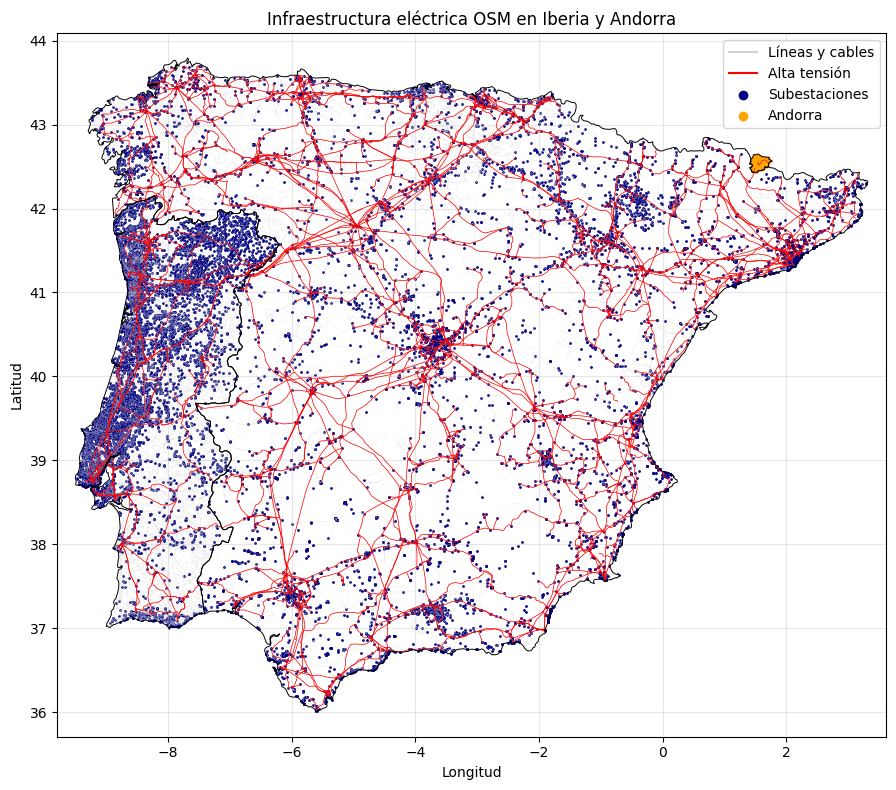

Mapa guardado en: /kaggle/working/06_infraestructura_electrica_osm_overpass_iberia/figures/mapa_infraestructura_electrica_iberia.png


In [13]:
# MAPA DE INFRAESTRUCTURA ELÉCTRICA
fig, ax = plt.subplots(figsize=(10, 8))
lineas_cables_gdf.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.15
)
lineas_alta_tension_gdf.plot(
    ax=ax,
    color="red",
    linewidth=0.5
)
subestaciones_representativas_gdf.plot(
    ax=ax,
    color="navy",
    markersize=1
)

# Límites territoriales
limites_tfb.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.7
)

# Destacar Andorra
limites_tfb[
    limites_tfb["ADM0_A3"] == "AND"
].plot(
    ax=ax,
    color="orange",
    edgecolor="darkorange"
)

# Leyenda
ax.plot([], [], color="lightgray", label="Líneas y cables")
ax.plot([], [], color="red", label="Alta tensión")
ax.scatter([], [], color="navy", label="Subestaciones")
ax.scatter([], [], color="orange", label="Andorra")
minx, miny, maxx, maxy = limites_tfb.total_bounds
ax.set(
    title="Infraestructura eléctrica OSM en Iberia y Andorra",
    xlabel="Longitud",
    ylabel="Latitud",
    xlim=(minx - 0.3, maxx + 0.3),
    ylim=(miny - 0.3, maxy + 0.3)
)
ax.legend()
ax.grid(alpha=0.3)
ruta_mapa_electrico = (
    FIGURES_DIR / "mapa_infraestructura_electrica_iberia.png"
)
plt.tight_layout()
plt.savefig(
    ruta_mapa_electrico,
    dpi=180,
    bbox_inches="tight"
)
plt.show()
print("Mapa guardado en:", ruta_mapa_electrico)

# Validación específica de Andorra

Comprobamos la cobertura eléctrica de Andorra mediante su límite territorial, sin realizar nuevas consultas a Overpass.

Los datos muestran 36 líneas o cables, 12 elementos de alta tensión y 8 subestaciones. Esta información confirma la presencia de infraestructura cartografiada, pero no permite conocer la capacidad disponible ni la viabilidad real de conexión.

In [14]:
# VALIDACIÓN DE ANDORRA
andorra_3035 = (
    limites_tfb[
        limites_tfb["ADM0_A3"] == "AND"
    ]
    .to_crs(CRS_METRICO)
    .geometry
    .union_all()
)
lineas_andorra_3035 = gpd.clip(
    lineas_cables_3035,
    andorra_3035
)
alta_tension_andorra_3035 = gpd.clip(
    lineas_alta_tension_3035,
    andorra_3035
)
subestaciones_andorra_3035 = gpd.clip(
    subestaciones_3035,
    andorra_3035
)
resumen_andorra = pd.DataFrame({
    "capa": [
        "Líneas y cables",
        "Alta tensión",
        "Subestaciones"
    ],
    "registros": [
        len(lineas_andorra_3035),
        len(alta_tension_andorra_3035),
        len(subestaciones_andorra_3035)
    ]
})
resumen_andorra.to_csv(
    TABLAS_DIR / "tabla_infraestructura_electrica_andorra.csv",
    index=False
)
print(
    "Cobertura Andorra:",
    "disponible"
    if resumen_andorra["registros"].sum() > 0
    else "sin datos"
)
display(resumen_andorra)

Cobertura Andorra: disponible


,capa,registros
0,Líneas y cables,36
1,Alta tensión,12
2,Subestaciones,8


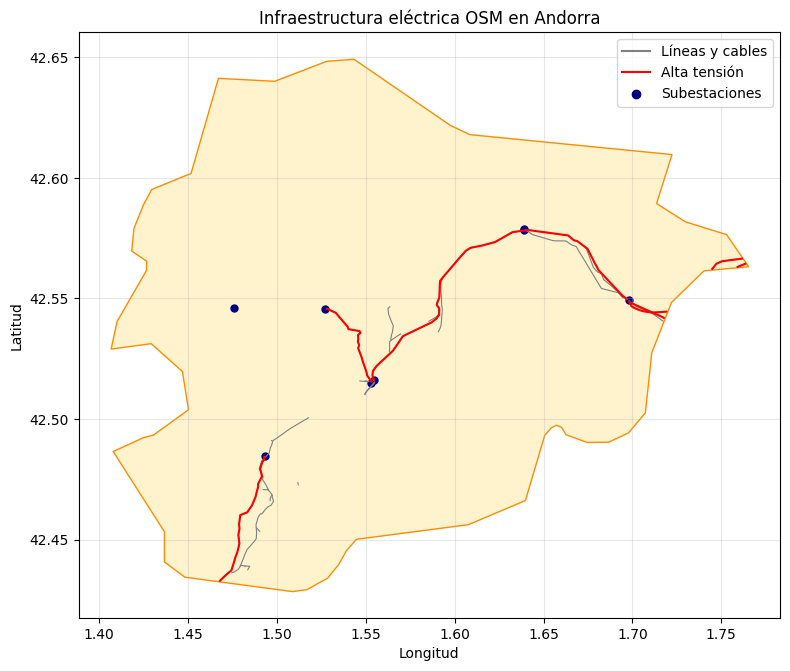

Mapa guardado en: /kaggle/working/06_infraestructura_electrica_osm_overpass_iberia/figures/mapa_infraestructura_electrica_andorra.png


In [15]:
# MAPA DE INFRAESTRUCTURA ELÉCTRICA DE ANDORRA
fig, ax = plt.subplots(figsize=(8, 7))
limite_andorra = limites_tfb[
    limites_tfb["ADM0_A3"] == "AND"
]
limite_andorra.plot(
    ax=ax,
    color="#fff3cd",
    edgecolor="darkorange"
)
lineas_andorra_3035.to_crs(
    CRS_GEOGRAFICO
).plot(
    ax=ax,
    color="gray",
    linewidth=0.8
)
alta_tension_andorra_3035.to_crs(
    CRS_GEOGRAFICO
).plot(
    ax=ax,
    color="red",
    linewidth=1.5
)
subestaciones_andorra_3035.to_crs(
    CRS_GEOGRAFICO
).plot(
    ax=ax,
    color="navy",
    markersize=25
)
ax.plot([], [], color="gray", label="Líneas y cables")
ax.plot([], [], color="red", label="Alta tensión")
ax.scatter([], [], color="navy", label="Subestaciones")
ax.set(
    title="Infraestructura eléctrica OSM en Andorra",
    xlabel="Longitud",
    ylabel="Latitud"
)
ax.legend()
ax.grid(alpha=0.3)
ruta_mapa_andorra = (
    FIGURES_DIR / "mapa_infraestructura_electrica_andorra.png"
)
plt.tight_layout()
plt.savefig(
    ruta_mapa_andorra,
    dpi=180,
    bbox_inches="tight"
)
plt.show()
print("Mapa guardado en:", ruta_mapa_andorra)

In [16]:
# GEOPACKAGE FINAL
ruta_gpkg_final = (
    GPKG_DIR
    / "infraestructura_electrica_iberia_osm_final_epsg3035.gpkg"
)
ruta_gpkg_final.unlink(missing_ok=True)
capas_finales = [
    ("lineas_cables_3035", lineas_cables_3035),
    (
        "lineas_cables_alta_tension_110kv_3035",
        lineas_alta_tension_3035
    ),
    (
        "subestaciones_representativas_3035",
        subestaciones_3035
    )
]
for numero, (nombre, capa) in enumerate(capas_finales):
    capa.to_file(
        ruta_gpkg_final,
        layer=nombre,
        driver="GPKG",
        mode="w" if numero == 0 else "a"
    )
print("GeoPackage final:", ruta_gpkg_final)
print("Capas guardadas:", len(capas_finales))

GeoPackage final: /kaggle/working/06_infraestructura_electrica_osm_overpass_iberia/processed/geopackage/infraestructura_electrica_iberia_osm_final_epsg3035.gpkg
Capas guardadas: 3


In [17]:
# RESUMEN FINAL
resumen_final = pd.DataFrame([{
    "origen": "Kaggle Input" if USAR_INPUT else "Overpass",
    "lineas_cables": len(lineas_cables_3035),
    "alta_tension": len(lineas_alta_tension_3035),
    "subestaciones": len(subestaciones_3035),
    "lineas_andorra": len(lineas_andorra_3035),
    "alta_tension_andorra": len(
        alta_tension_andorra_3035
    ),
    "subestaciones_andorra": len(
        subestaciones_andorra_3035
    ),
    "crs": CRS_METRICO,
    "estado": "completado",
    "fecha_ejecucion": FECHA_EJECUCION
}])
resumen_final.to_csv(
    TABLAS_DIR / "tabla_resumen_final_electrico.csv",
    index=False
)
display(resumen_final)

,origen,lineas_cables,alta_tension,subestaciones,lineas_andorra,alta_tension_andorra,subestaciones_andorra,crs,estado,fecha_ejecucion
0,Kaggle Input,124709,11450,23366,36,12,8,EPSG:3035,completado,2026-09-18 13:44:21


In [18]:
# DASHBOARD HTML
import base64

def incrustar_imagen(ruta):
    imagen = base64.b64encode(
        ruta.read_bytes()
    ).decode("utf-8")
    return f"data:image/png;base64,{imagen}"
r = resumen_final.iloc[0]

html = f"""
<html>
<head>
<meta charset="UTF-8">
<title>Infraestructura eléctrica</title>
<style>
body {{font-family: Arial; margin: 30px;}}
img {{width: 100%; max-width: 900px;}}
li {{margin: 8px;}}
</style>
</head>
<body>
<h1>Infraestructura eléctrica de Iberia y Andorra</h1>
<ul>
<li>Líneas y cables: {r["lineas_cables"]:,}</li>
<li>Alta tensión: {r["alta_tension"]:,}</li>
<li>Subestaciones: {r["subestaciones"]:,}</li>
<li>Líneas en Andorra: {r["lineas_andorra"]}</li>
<li>Alta tensión en Andorra: {r["alta_tension_andorra"]}</li>
<li>Subestaciones en Andorra: {r["subestaciones_andorra"]}</li>
</ul>
<h2>Mapa general</h2>
<img src="{incrustar_imagen(ruta_mapa_electrico)}">
<h2>Detalle de Andorra</h2>
<img src="{incrustar_imagen(ruta_mapa_andorra)}">
<p>
Los datos OSM permiten analizar proximidad territorial,
pero no garantizan capacidad ni viabilidad de conexión.
</p>

</body>
</html>
"""
ruta_dashboard = (
    DASHBOARD_DIR / "dashboard_infraestructura_electrica.html"
)
ruta_dashboard.write_text(html, encoding="utf-8")

print("Dashboard guardado en:", ruta_dashboard)

Dashboard guardado en: /kaggle/working/06_infraestructura_electrica_osm_overpass_iberia/dashboard/dashboard_infraestructura_electrica.html


In [19]:
# ZIP FINAL
import zipfile

ruta_zip_final = (
    BASE_DIR
    / "06_infraestructura_electrica_iberia_andorra_final.zip"
)
archivos = [
    ruta_gpkg_final,
    ruta_mapa_electrico,
    ruta_mapa_andorra,
    ruta_dashboard,
    ruta_limites,
    *TABLAS_DIR.glob("*.csv")
]
ruta_zip_final.unlink(missing_ok=True)

with zipfile.ZipFile(
    ruta_zip_final,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:
    for archivo in archivos:
        if archivo.exists():
            zipf.write(
                archivo,
                archivo.relative_to(OUT_DIR)
            )

print("ZIP final:", ruta_zip_final)
print("Archivos:", len(archivos))
print(
    "Tamaño MB:",
    round(ruta_zip_final.stat().st_size / 1024**2, 2)
)

ZIP final: /kaggle/working/06_infraestructura_electrica_iberia_andorra_final.zip
Archivos: 14
Tamaño MB: 30.19


# Interpretación metodológica

Este notebook construye el bloque de infraestructura eléctrica para España peninsular, Portugal continental y Andorra.

Utilizamos datos de OpenStreetMap procesados previamente y disponibles en Kaggle Input. Overpass API queda como alternativa de descarga trazable cuando estos datos no estén disponibles. Realizamos el recorte territorial con límites de Natural Earth para excluir Francia, África y los territorios insulares.

Los resultados finales incluyen:

- 124.709 líneas y cables;
- 11.450 líneas y cables de alta tensión;
- 23.366 subestaciones;
- cobertura específica de Andorra con 36 líneas, 12 elementos de alta tensión y 8 subestaciones.

La clasificación de alta tensión considera elementos con valores iguales o superiores a 110 kV cuando el atributo `voltage` está disponible.

Estas capas las usamos para calcular indicadores territoriales de infraestructura eléctrica. En el IIT-CPD final lo usamos en la densidad de líneas de alta tensión (≥110 kV) y la densidad de subestaciones. OSM permite aproximar la presencia y distribución de esta infraestructura, pero no informa sobre capacidad disponible, congestión, costes ni viabilidad real de conexión.

El archivo principal para los notebooks posteriores es:

`processed/geopackage/infraestructura_electrica_iberia_osm_final_epsg3035.gpkg`